# 42) Üstel Dağılım (Exponential Distribution)
Üstel Dağılım, bir olayın gerçekleşmesinden sonra **bir sonraki olaya kadar geçen süreyi** modelleyen sürekli bir olasılık dağılımıdır. Poisson Dağılımı "belirli bir sürede kaç olay olur" sorusuna cevap verirken, Üstel Dağılım "bir sonraki olaya kadar ne kadar süre geçer" sorusuna cevap verir ikisi birbirinin tamamlayıcısıdır ve genelde aynı λ parametresini paylaşırlar.

## Parametre
- **λ (lambda):** Poisson'daki ile aynı oran (örn: saatte ortalama kaç müşteri geldiği)
- Bazı kütüphaneler (SciPy dahil) bunun yerine **β = 1/λ** (ortalama bekleme süresi) kullanır hangi parametrenin kullanıldığına dikkat etmek gerekir.

## Olasılık Yoğunluk Fonksiyonu (PDF)
$$f(x) = \lambda e^{-\lambda x}, \quad x \ge 0$$

## Beklenen Değer ve Varyans
$$E(X) = \frac{1}{\lambda} \qquad Var(X) = \frac{1}{\lambda^2}$$

## Dağılımın Şekli
Üstel Dağılım her zaman **sağa çarpıktır**:
- 0'dan başlar (negatif süre mümkün değil).
- Tepe noktası 0'a en yakın bölgededir kısa bekleme süreleri en olasıdır.
- Süre uzadıkça olasılık gittikçe azalır, uzun bir sağ kuyruk oluşur.

## Hafızasızlık (Memorylessness) Özelliği
Üstel Dağılım'ın kendine özgü ve ilginç bir özelliği vardır: geçmişte ne kadar süre beklenmiş olursa olsun, **gelecekteki bekleme süresinin olasılık dağılımı değişmez.** Yani süreç "daha önce ne kadar beklendiğini" hesaba katmaz her an sanki "sıfırdan" başlıyormuş gibi davranır. Bu, Bernoulli/Binom'daki "denemelerin bağımsızlığı" fikrinin (Konu 39-40), zaman/süreklilik boyutuna uygulanmış halidir.

## Kullanım Alanları
- Bir müşterinin churn etmesine kadar geçen süre (customer lifetime).
- İki sipariş arasındaki bekleme süresi.
- Bir makinenin arızalanmasına kadar geçen süre.
- Bir destek talebine yanıt verilmesine kadar geçen süre.

## Poisson ile İlişki (Özet Tablo)
| | Poisson | Üstel |
|:---:|---|---|
| Ne ölçer | Belirli sürede kaç olay | Bir sonraki olaya kadar süre |
| Veri tipi | Kesikli (sayı) | Sürekli (süre) |
| Ortak parametre | λ | λ (veya 1/λ) |

Teorik Beklenen Değer (ortalama bekleme süresi): 0.2500 saat (15.0 dakika)
Teorik Varyans: 0.0625

Bir sonraki müşterinin 20 dakikadan fazla sürede gelme olasılığı: 0.2636

Deneysel Ortalama Bekleme Süresi: 0.2444 saat
Deneysel olarak bir sonraki müşterinin 20 dakikadan fazla sürede gelme olasılığı: 0.2539


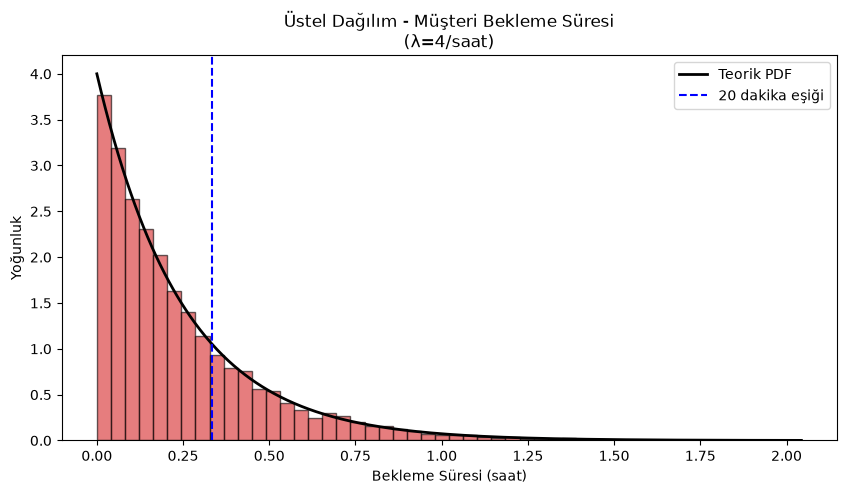

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- Senaryo: Mağazaya saatte ortalama 4 müşteri geliyor (λ=4) ---
lambda_musteri = 4  # saatte ortalama 4 müşteri

# SciPy'de expon fonksiyonu scale = 1/λ parametresini kullanır (dikkat!)
beta = 1 / lambda_musteri  # ortalama bekleme süresi (saat cinsinden)

# --- Teorik Değerler ---
teorik_E = 1 / lambda_musteri
teorik_var = 1 / (lambda_musteri ** 2)
print(f"Teorik Beklenen Değer (ortalama bekleme süresi): {teorik_E:.4f} saat ({teorik_E*60:.1f} dakika)")
print(f"Teorik Varyans: {teorik_var:.4f}")

# --- Soru: Bir sonraki müşterinin 20 dakikadan (1/3 saat) fazla sürede gelme olasılığı ---
esik_saat = 20 / 60  # 20 dakikayı saate çeviriyoruz
olasilik_20dk_uzeri = 1 - stats.expon.cdf(esik_saat, scale=beta)
print(f"\nBir sonraki müşterinin 20 dakikadan fazla sürede gelme olasılığı: {olasilik_20dk_uzeri:.4f}")

# --- Simülasyon ---
np.random.seed(42)
bekleme_sureleri = stats.expon.rvs(scale=beta, size=10000)

print(f"\nDeneysel Ortalama Bekleme Süresi: {np.mean(bekleme_sureleri):.4f} saat")
deneysel_olasilik = np.mean(bekleme_sureleri > esik_saat)
print(f"Deneysel olarak bir sonraki müşterinin 20 dakikadan fazla sürede gelme olasılığı: {deneysel_olasilik:.4f}")

# --- Görselleştirme ---
plt.figure(figsize=(10,5))
plt.hist(bekleme_sureleri, bins=50, density=True, color='C3', alpha=0.6, edgecolor='black')

x = np.linspace(0, bekleme_sureleri.max(), 500)
y = stats.expon.pdf(x, scale=beta)
plt.plot(x, y, color='black', linewidth=2, label='Teorik PDF')

plt.axvline(esik_saat, color='blue', linestyle='--', label='20 dakika eşiği')
plt.title(f"Üstel Dağılım - Müşteri Bekleme Süresi\n(λ={lambda_musteri}/saat)")
plt.xlabel("Bekleme Süresi (saat)")
plt.ylabel("Yoğunluk")
plt.legend()
plt.show()

### Sonuç
Yukarıda simüle ettiğimiz üstel dağılıma ait formülden elde ettiğimiz sonuçlar ile yaptığımız 10000 gözlemlik deneye ait sonuçların neredeyse birbirine eşit olduğunu gözlemlemekteyiz. Ayrıca bekleme süresinin arttıkça bu sürenin gözlenme olasılığının da git gide düştüğünü görüyoruz.